# Argon A-to-Z

This tutorial demonstrates a-to-z how to optimise Lennard Jones parameters for liquid argon, and without going into details. For details see other tutorials and wider MDMC documentation.

In [1]:
# Imports used for this tutorial
import numpy as np
import matplotlib.pyplot as plt
import os
from MDMC.control import Control
from MDMC.MD import Atom, Dispersion, LennardJones, Simulation, Universe

Supported DL_POLY version 4.10


In [2]:
# Change the number of threads depending on the number of physical cores on your computer
# as it was tested for LAMMPS
os.environ["OMP_NUM_THREADS"] = "4"

In [3]:
# Build universe with density 0.0176 atoms per AA^-3
density = 0.0176
# This means cubic universe of side:
# 23.0668 A will contain 216 Ar atoms
# 26.911 A will contain 343 Ar atoms
# 30.7553 A will contain 512 Ar atoms
# 38.4441 A will contain 1000 Ar atoms
universe = Universe(dimensions=23.0668)
Ar = Atom('Ar', charge=0.)
# Calculating number of Ar atoms needed to obtain density
n_ar_atoms = int(density * np.product(universe.dimensions))
print(f'Number of argon atoms = {n_ar_atoms}')
universe.fill(Ar, num_struc_units=(n_ar_atoms))

Universe created with:
  Dimensions       [23.07, 23.07, 23.07]
  Force field                       None
  Number of atoms                      0

Number of argon atoms = 216


In the Jupyter cell above, a box of Argon atoms is set up. However, at this point there is no interaction forces between the argon atoms! In the cell below an appropriate (for argon) force-field interaction potential is defined.

In [4]:
Ar_dispersion = Dispersion(universe,
                           (Ar.atom_type, Ar.atom_type),
                           cutoff=8.,
                           function=LennardJones(epsilon=1.0243, sigma=3.36))

In this case the interaction potential chosen is the humble Lennard Jones (to get info see doc or type `help(LennardJones)`).

Also, a `cutoff` value is chosen (see `help(Dispersion)` for more info). A [rule of thumb for Lennard-Jones](https://en.wikipedia.org/wiki/Lennard-Jones_potential) is to pick `cutoff=2.5*sigma`. The value for argon is recommended to be between 8 and 12 ang. `cutoff` is not a force-field parameter and therefore will not be refined. Ideally, and for any system you want to pick at value of the `cutoff` which is small while not compromising accuracy. For this system picking a value between 8 and 12 ang is found to give near identifical results.

Next (and before starting the refinement), we set up the MD engine and equilibrate the system. Note with MDMC the equilibration only needs to be done once. 

In [5]:
# MD Engine setup
simulation = Simulation(universe,
                        engine="lammps",
                        time_step=10.18893,
                        temperature=120.,
                        traj_step=15)

LAMMPS (29 Sep 2021 - Update 2)
  using 4 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
LAMMPS (29 Sep 2021 - Update 2)
  using 4 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
Total wall time: 0:00:00
Simulation created with lammps engine and settings:
  temperature  120.0



In [6]:
# Energy Minimization and equilibration
simulation.minimize(n_steps=5000)
simulation.run(n_steps=10000, equilibration=True)

OK; time to set up the actual refinement of the force-field parameters. 

First we need some data to refine against:

In [7]:
# exp_datasets is a list of dictionaries with one dictionary per experimental
# dataset
# Dataset from: van Well et al. (1985). Physical Review A, 31(5), 3391-3414
# resolution is None as the original author already accounted for instrument resolution
exp_datasets = [{'file_name':'data/Well_s_q_omega_Ar_data.xml',
                 'type':'SQw',
                 'reader':'xml_SQw',
                 'weight':1.,
                 'auto_scale':True,
                 'resolution':None}]

The number of `MD_steps` specified must be large enough to allow for successful calculation of all observables. This depends the `type` of the dataset provided and the value of the `traj_step` (specified when creating the `Simulation`). If a value for `MD_steps` is not provided, then the minimum number needed will be used automatically.

Additionally, some observables will have an upper limit on the number of MD_steps that can be used in calculating their dependent variable(s). In these cases, the number of `MD_steps` is rounded down to a multiple of this upper limit so that we only run steps that will be useful. For example, if we use 1000 `MD_steps` in calculation, but a value of 2500 is provided, then we will run 2000 steps and use this to calculate the variable twice, without wasting time performing an additional 500 steps.

In [8]:
fit_parameters = universe.parameters
fit_parameters['sigma'].constraints = [2.8,3.8]
fit_parameters['epsilon'].constraints = [0.7, 1.2]


control = Control(simulation=simulation,
                  exp_datasets=exp_datasets,
                  fit_parameters=fit_parameters,
                  minimizer_type="GPO",
                  reset_config=True,
                  MD_steps=1000, 
                  equilibration_steps=2000,
                  n_points=30)

Control created with:
  Minimizer                             GPO
  FoM type               ChiSquaredExpError
  Number of observables                   1
  Number of parameters                    2



And finally start the refinement! Bump up `n_steps` from 3 when you are ready.

In [9]:
# Run the refinement, i.e. refine the FF parameters against the data
control.refine(n_steps=30)

Step         FoM Change state  Pred coords     Pred FoM epsilon (#2)   sigma (#3)
   0       393.9     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9        1.024         3.36
   1       502.4     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.9719        3.532
   2       690.7     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.9969        2.905
   3        1026     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.9098        3.782
   4       483.3     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9        1.198         3.47
   5       665.6     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.7743        2.876
   6       511.2     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.8962        3.198
   7         636     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.8297        3.693
   8       436.3     Accepted [1.0243 kJ / mol, 3.36 Ang]        393.9       0.7088        3.271
   9       983.6     Accepted [1.0243 kJ / mo

In [10]:
help(control.minimizer.optimizer.get_result()['models'][0])

Help on GaussianProcessRegressor in module skopt.learning.gaussian_process.gpr object:

class GaussianProcessRegressor(sklearn.gaussian_process._gpr.GaussianProcessRegressor)
 |  GaussianProcessRegressor(kernel=None, alpha=1e-10, optimizer='fmin_l_bfgs_b', n_restarts_optimizer=0, normalize_y=False, copy_X_train=True, random_state=None, noise=None)
 |  
 |  GaussianProcessRegressor that allows noise tunability.
 |  
 |  The implementation is based on Algorithm 2.1 of Gaussian Processes
 |  for Machine Learning (GPML) by Rasmussen and Williams.
 |  
 |  In addition to standard scikit-learn estimator API,
 |  GaussianProcessRegressor:
 |  
 |     * allows prediction without prior fitting (based on the GP prior);
 |     * provides an additional method sample_y(X), which evaluates samples
 |       drawn from the GPR (prior or posterior) at given inputs;
 |     * exposes a method log_marginal_likelihood(theta), which can be used
 |       externally for other ways of selecting hyperparameters

In [11]:
point = (0.4,3.0)
def predicter(*input):
    point = np.array([input])
    Foms=[]
    for model in control.minimizer.optimizer.get_result()['models']:
        Foms.append(model.predict(point.reshape(1,-1)))
    return np.mean(Foms)*-2.0

predicter(point)

-1096.0035763785775

In [12]:
print((control.minimizer.optimizer.max_model_queue_size))#.space)
#np.mean(control.minimizer.optimizer.get_result()['models'][11].sample_y(np.array([0.7026,3.450]).reshape(1,-1), n_samples=10000)), np.std(control.minimizer.optimizer.get_result()['models'][11].sample_y(np.array([0.7026,3.450]).reshape(1,-1), n_samples=10000))

1


In [13]:
print(control.minimizer.optimizer.models[0])
print((control.minimizer.optimizer.get_result()['models'][-1]))

GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=[1, 1], nu=2.5) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=2, noise='gaussian',
                         normalize_y=True, random_state=327741615)
GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=[1, 1], nu=2.5) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=2, noise='gaussian',
                         normalize_y=True, random_state=327741615)


In [14]:
print(np.array([0.7,3.45]).reshape(1,-1))
print([[0.7, 3.45]])

[[0.7  3.45]]
[[0.7, 3.45]]


In [15]:
from skopt import expected_minimum_random_sampling

In [19]:
def expected_minimum_random_samplingj(res, n_random_starts=100000,
                                     random_state=None):
    """https://github.com/scikit-optimize/scikit-optimize/blob/de32b5fd2205a1e58526f3cacd0422a26d315d0f/skopt/utils.py#L259

    Parameters
    ----------
    res : `OptimizeResult`, scipy object
        The optimization result returned by a `skopt` minimizer.
    n_random_starts : int, default=100000
        The number of random starts for the minimization of the surrogate
        model.
    random_state : int, RandomState instance, or None (default)
        Set random state to something other than None for reproducible
        results.
    Returns
    -------
    x : list
        location of the minimum.
    fun : float
        the surrogate function value at the minimum.
    """

    # sample points from search space
    random_samples = res.space.rvs(n_random_starts, random_state=random_state)

    # make estimations with surrogate
    model = res.models[-1]
    y_random = model.predict(res.space.transform(random_samples))
    index_best_objective = np.argmin(y_random)
    min_x = random_samples[index_best_objective]

    return min_x, y_random[index_best_objective], y_random, random_samples

In [51]:
_, _, y_ran, coords = expected_minimum_random_samplingj(control.minimizer.optimizer, n_random_starts=100000)

(100000, 3)


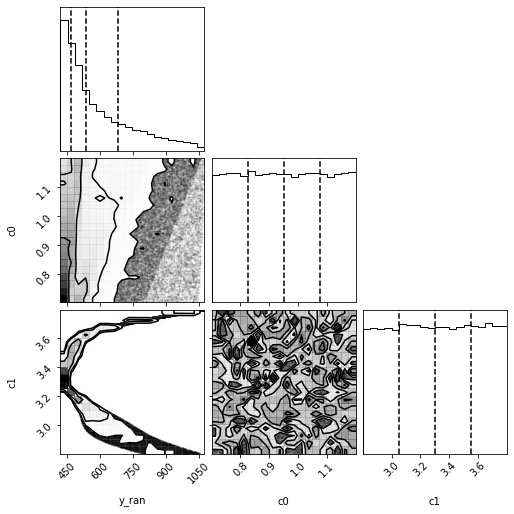

In [53]:
from arviz import convert_to_dataset
import corner

y_ran= np.array(y_ran)
c0 = np.array(coords)[:,0]
c1 = np.array(coords)[:,1]
data = np.array([y_ran, c0, c1])
data = data.T
print(data.shape)
labels = [str(name) for name in ['y_ran', 'c0', 'c1']]
kwds = {}
kwds["labels"] = labels
kwds["quantiles"] = [0.25, 0.5, 0.75]
corner.corner(data, **kwds);

In [ ]:
import emcee
from scipy.optimize import minimize

x = fit_parameters['sigma'].value
y = fit_parameters['epsilon'].value
initial = (x, y)


nll = lambda *args: predicter(*args)
soln = minimize(nll, initial, args=(x, y))
#sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y))
#sampler.run_mcmc(soln, 5000, progress=True)


In [ ]:
import emcee
from scipy.optimize import minimize

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))


np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True)


In [ ]:
sampler.get_chain().shape

In [ ]:
import corner
corner.corner(test)